## Weather data

Most crop simulations require weather input data. Most commonly:
    - Solar irradiance (MJ/m2/day)
    - Precipation (mm/month)
    
And less important
    - Days with rain (1/month)
    
This demo comes with weather data files which can be found in the inputs folder.
    
**Note, these input files can for instance be opened/altered in Excel.**

In [1]:
# import pandas --- spreadsheet library
import pandas as pd

# import matplotlib --- plotting library
import matplotlib.pyplot as plt 

In [2]:
%matplotlib inline

In [3]:
import os

fpath = '../../data/agrifood/KBD - 2006.xlsx'
dfo = pd.read_excel(fpath)

fpath = '../../data/agrifood/KBL - 2006 - weather.xlsx'
dfw = pd.read_excel(fpath)

In [4]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from palmsim import PalmField

# 1. Initialize the model
p = PalmField(year_of_planting=2003, month_of_planting= 6)

# 2. Couple the solar radiation data:
p.weather.radiation_series = dfw['Irradiation (MJ/m2/d)'].resample('D').pad()

s = dfw['Precipitation (mm/month)'].resample('D').pad()
s = s/s.index.days_in_month

p.weather.rainfall_series = s

#p.weather.rainfall_series = s

In [5]:
tw0, tw1 = dfw.index[0], dfw.index[-1]
tw0, tw1

(Timestamp('2006-01-01 00:00:00'), Timestamp('2017-12-01 00:00:00'))

In [6]:
p.date

'2003-6-1'

In [7]:
#%prun p.update()

In [8]:
p.weather

Object: Weather

Property                                     Value Unit        
--------------------------------------------------------------
PAR                                          8.625  MJ/m2/day   
daylength                                   12.000  ?           
fraction_diffuse                             0.649  ?           
hour_of_dawn                                 6.000  ?           
hour_of_dusk                                18.000  ?           
radiation                                   17.250  MJ/m2/day   
radiation_extraterrestrial                1308.674  ?           
radiation_extraterrestrial_daily            34.858  ?           
radiation_series_mean                       17.250  MJ/m2/day   
raindays                                    14.000  1/mo        
raindays_series_mean                        14.000  1/mo        
rainfall                                     5.469  mm/day      
rainfall_series_mean                         5.469  mm/day      
sine_solar_

In [10]:
p.fronds

Object: Fronds

Property                                     Value Unit        
--------------------------------------------------------------
LUE                                          3.800  g_CH2O/MJ PAR
LUE2                                         0.467  ?           
assim_growth                                18.935  kg_CH2O/ha/day
assim_produced                              38.197  kg_CH2O/ha/day
assim_produced2                             40.666  ?           
count                                     4140.000  1/ha        
count_change_rate                           15.879  1/ha/day    
count_growth_rate                           15.879  1/ha/day    
count_loss_rate                              0.000  1/ha/day    
count_per_palm                              30.000  1/palm      
fraction_intercepted                         0.131  1           
initiation_rate                              0.115  1/palm/day  
intercepted_PAR                             11.281  GJ/ha/day   
leaf_ar

In [11]:
import time
import tqdm

In [12]:
t0 = time.time()

dt = 3

p.dt = dt

nyears = 20

duration = nyears*365
nsteps = duration//dt

res = {}

for i in tqdm.tqdm(range(nsteps)):
    
    p.update(dt=dt)
    
    res[i] = p.to_dict()
    
t1 = time.time()

print(t1 - t0)

100%|██████████████████████████████████████| 2433/2433 [01:18<00:00, 31.13it/s]


78.17834043502808


In [13]:
import pandas as pd

df = pd.DataFrame(res).T

In [14]:
df = df.set_index(pd.to_datetime(df['date']))

13149.0
2006-01-01 00:00:00


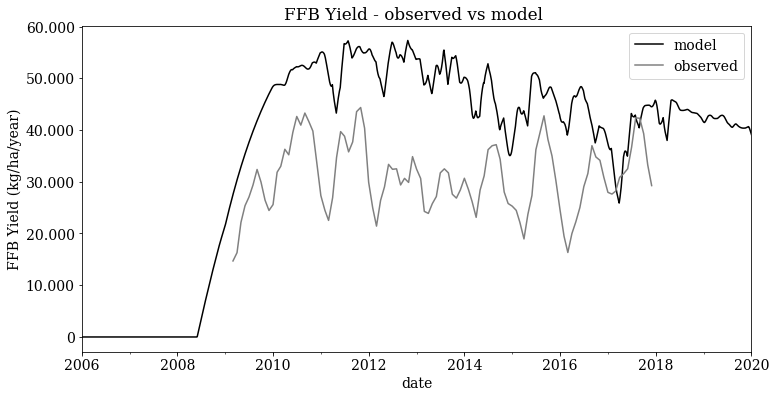

In [15]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14

fig, ax = plt.subplots(figsize=(12,6))

df['generative_FFB_production (t/ha/yr)'].plot(ax=ax,color='black',ls='solid', label='model')

(12*1000*dfo['Y (t/ha/mo)']).rolling(3,center=True).mean().plot(ax=ax, color='grey', label='observed')

ax.set_xlim('2006','2020')

t0, t1 = ax.get_xlim()

print(t0)
print(tw0)

y0, y1 = ax.get_ylim()

#ax.fill_between([t0,tw0],0, y1)
#ax.fill_between([tw1,t1],0, y1, color='grey', alpha=0.1, label='no weather data')

ax.set_yticklabels(["{:,}".format(int(y)).replace(',','.') for y in ax.get_yticks()])

ax.set_ylabel('FFB Yield (kg/ha/year)')

ax.set_title('FFB Yield - observed vs model ')

ax.legend()

plt.savefig('out.png', dpi=300)

In [16]:
xs = df['generative_FFB_production (t/ha/yr)'].astype(float).resample('M').mean()
ys = (12*1000*dfo['Y (t/ha/mo)']).resample('M').mean()

index = ys.index

In [17]:
xs_ = xs[index]

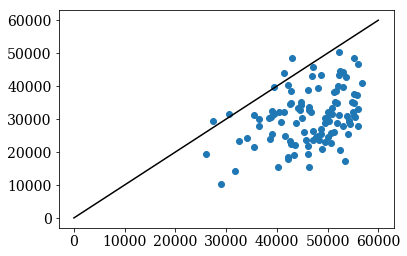

In [18]:
fig,ax = plt.subplots()
ax.scatter(xs_,ys)

ax.plot([0,60000],[0,60000], color='black')

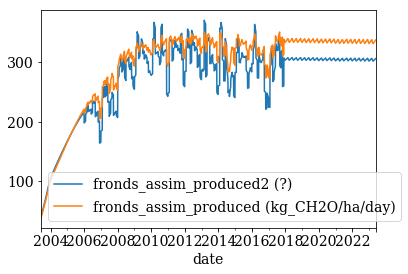

In [21]:
ax = df['fronds_assim_produced2 (?)'].plot()
df['fronds_assim_produced (kg_CH2O/ha/day)'].plot(ax=ax)
#ax.set_xlim('2006','2020')
ax.legend()

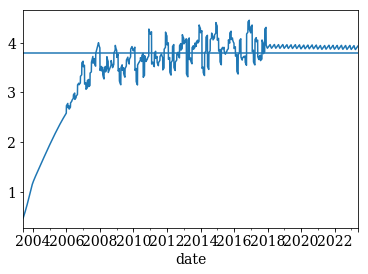

In [22]:
ax = df['fronds_LUE2 (?)'].plot()
ax.axhline(3.8)

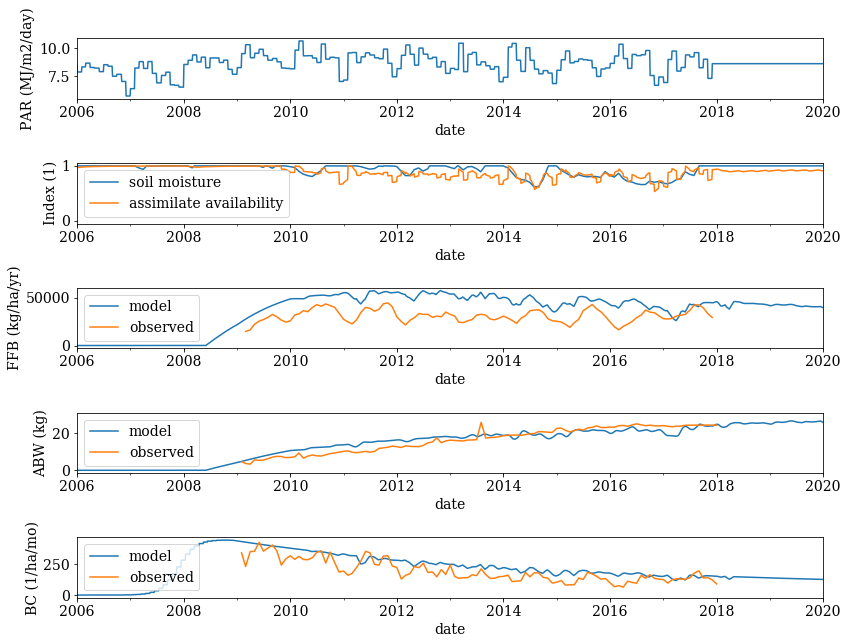

In [23]:
fig, axes = plt.subplots(5,1, figsize=(12,9))

ax = axes[0]
df['weather_PAR (MJ/m2/day)'].plot(ax=ax, label='PAR (MJ/m2/day)')
ax.set_ylabel('PAR (MJ/m2/day)')
ax.set_xlim('2006','2020')

ax = axes[1]
df['soil_moisture_content (1)'].plot(ax=ax, label='soil moisture')
df['generative_Ic (1)'].plot(ax=ax, label='assimilate availability')
ax.legend()
ax.set_ylabel('Index (1)')
ax.set_xlim('2006','2020')

ax = axes[2]
df['generative_FFB_production (t/ha/yr)'].plot(ax=ax, label='model')
(12*1000*dfo['Y (t/ha/mo)']).rolling(3,center=True).mean().plot(ax=ax, label='observed')
ax.set_ylabel('FFB (kg/ha/yr)')
ax.set_xlim('2006','2020')
ax.legend()

ax = axes[3]
(2*df['generative_bunch_weight (kg_DM)']).plot(ax=ax, label='model')
dfo['ABW (kg)'].plot(ax=ax, label='observed')
ax.set_ylabel('ABW (kg)')
ax.legend()
ax.set_xlim('2006','2020')

ax = axes[4]
((365/12)*df['generative_bunch_count (1/ha/day)']).plot(ax=ax, label='model')
ax = (dfo['BC (1/ha/mo)']).plot(ax=ax, label='observed')
ax.legend()
ax.set_ylabel('BC (1/ha/mo)')
ax.set_xlim('2006','2020')

plt.tight_layout()

(13149, 18262)

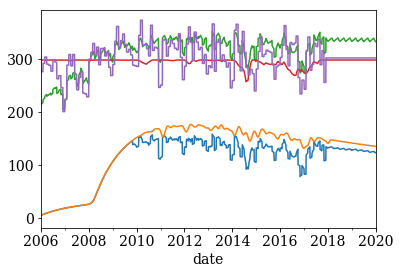

In [28]:
ax = df['generative_assim_growth (kg_DM/ha/day)'].plot()
df['generative_potential_sink_strength (kg_CH2O/ha/day)'].plot(ax=ax)
df['assimilates_assim_produced (kg_CH2O/ha/day)'].plot(ax=ax)
(300*df['soil_relative_transpiration_rate (1)']).plot()
(35*df['weather_PAR (MJ/m2/day)']).plot()
ax.set_xlim('2006','2020')

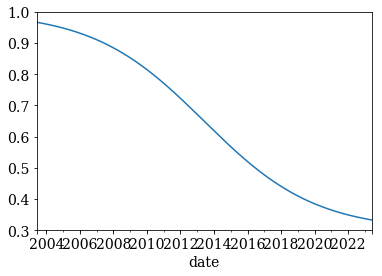

In [29]:
df['generative_female_fraction (1)'].plot()

(13149, 18262)

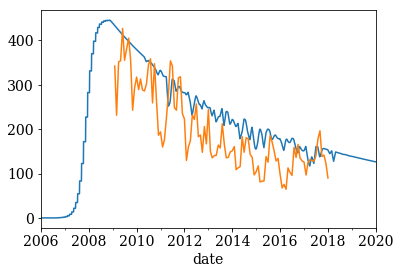

In [30]:
((365/12)*df['generative_bunch_count (1/ha/day)']).plot()
ax = (dfo['BC (1/ha/mo)']).plot()
ax.set_xlim('2006','2020')

(13149, 18262)

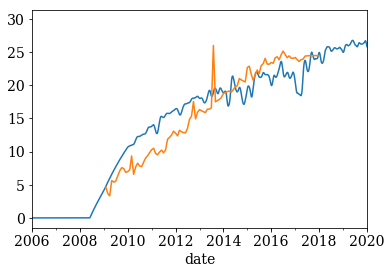

In [31]:
(2*df['generative_bunch_weight (kg_DM)']).plot()
ax = dfo['ABW (kg)'].plot()
ax.set_xlim('2006','2020')

(13149, 18262)

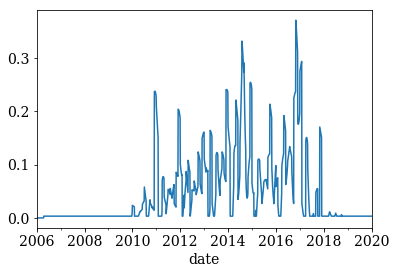

In [34]:
ax = (30*df['generative_bunch_failure_fraction (1)']).plot()
ax.set_xlim('2006','2020')

(13149, 18262)

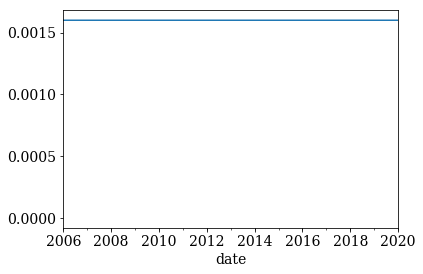

In [35]:
ax = (30*df['generative_inflorescence_abortion_fraction (1)']).plot()
ax.set_xlim('2006','2020')

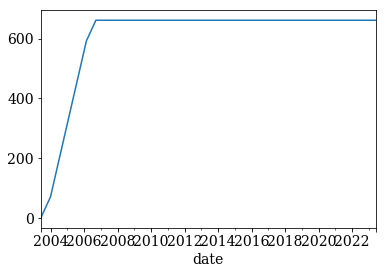

In [33]:
df['generative_number_of_cohorts (1)'].plot()

In [ ]:
df['fronds_assim_produced (kg_CH2O/ha/day)'].plot()

In [ ]:
df['soil_moisture_content (1)'].plot()

In [ ]:
p.fronds

In [ ]:
p.generative

In [ ]:
p.soil.available_water, p.soil.available_water_change_rate,

In [ ]:
p.assimilates

In [ ]:
cohort = p.generative.cohorts[0]

In [ ]:
cohort